In [71]:
import pandas as pd #hago las importaciones de librerias.
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [72]:
import warnings # para que no se imprimam los future warning
warnings.filterwarnings('ignore', category=FutureWarning)

In [73]:
pd.set_option('display.max_columns', None) 

In [74]:
df_limpio = pd.read_csv("Files/df_limpio.csv")

In [75]:
df_limpio.describe().T # imprimo la información del dataframe para saber los tipos de datos que tengo y poder elegir cuales quiero analizar.

,count,mean,std,min,25%,50%,75%,max
loyalty_number,403760.0,549875.383713,258961.514684,100018.00,326699.00,550598.00,772152.00,999986.00
year,403760.0,2017.500352,0.500000,2017.00,2017.00,2018.00,2018.00,2018.00
month,403760.0,6.501335,3.451982,1.00,4.00,7.00,10.00,12.00
flights_booked,403760.0,4.134050,5.230064,0.00,0.00,1.00,8.00,21.00
flights_with_companions,403760.0,1.036569,2.080472,0.00,0.00,0.00,1.00,11.00
total_flights,403760.0,5.170619,6.526858,0.00,0.00,1.00,10.00,32.00
distance,403760.0,1214.460979,1434.098521,0.00,0.00,525.00,2342.00,6293.00
points_accumulated,403760.0,124.263761,146.696179,0.00,0.00,53.00,240.00,676.50
points_redeemed,403760.0,30.838587,125.758002,0.00,0.00,0.00,0.00,876.00
dollar_cost_points_redeemed,403760.0,2.495973,10.172033,0.00,0.00,0.00,0.00,71.00


In [76]:
columnas_num= ['flights_booked', 'total_flights', 'distance','points_accumulated', 'dollar_cost_points_redeemed','salary', 'clv'] # elijo las columnas numericas relevantes para el analisis estadistico.
estadisticas_num= df_limpio[columnas_num].agg(['mean', 'median', 'std', 'min', 'max']) # calculo la media, mediana, desviación estándar, mínimo y máximo para cada una de las columnas numéricas relevantes y las guardo en un nuevo dataframe llamado "estadisticas_num".
estadisticas_num.T .round(2)  # imprimo el nuevo dataframe transpuesto y redondeado.

,mean,median,std,min,max
flights_booked,4.13,1.00,5.23,0.00,21.00
total_flights,5.17,1.00,6.53,0.00,32.00
distance,1214.46,525.00,1434.10,0.00,6293.00
points_accumulated,124.26,53.00,146.70,0.00,676.50
dollar_cost_points_redeemed,2.50,0.00,10.17,0.00,71.00
salary,77879.28,73479.00,30117.57,9081.00,407228.00
clv,7990.86,5776.34,6863.32,1898.01,83325.38


In [77]:
estadisticas_num.loc['mode'] = df_limpio[columnas_num].mode().iloc[0] # calculo la moda para las columnas numéricas relevantes y la añado al dataframe "estadisticas_num" como una nueva fila llamada "mode".  
estadisticas_num.T .round(2) # imprimo el dataframe "estadisticas_num" transpuesto y redondeado.

,mean,median,std,min,max,mode
flights_booked,4.13,1.00,5.23,0.00,21.00,0.00
total_flights,5.17,1.00,6.53,0.00,32.00,0.00
distance,1214.46,525.00,1434.10,0.00,6293.00,0.00
points_accumulated,124.26,53.00,146.70,0.00,676.50,0.00
dollar_cost_points_redeemed,2.50,0.00,10.17,0.00,71.00,0.00
salary,77879.28,73479.00,30117.57,9081.00,407228.00,73479.00
clv,7990.86,5776.34,6863.32,1898.01,83325.38,8564.77


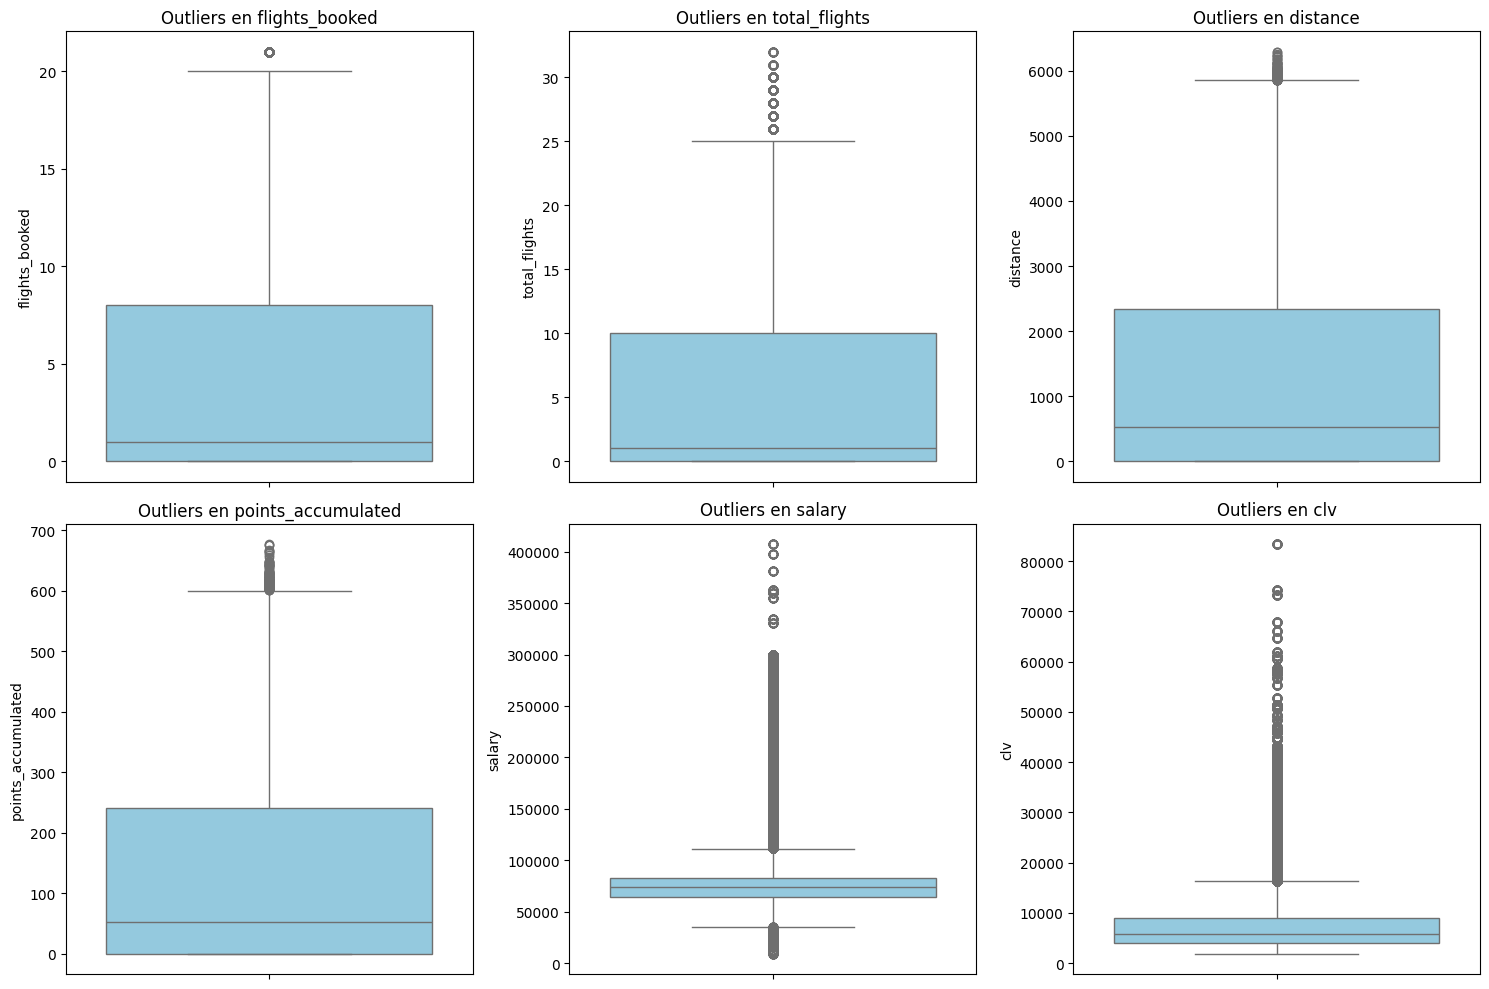

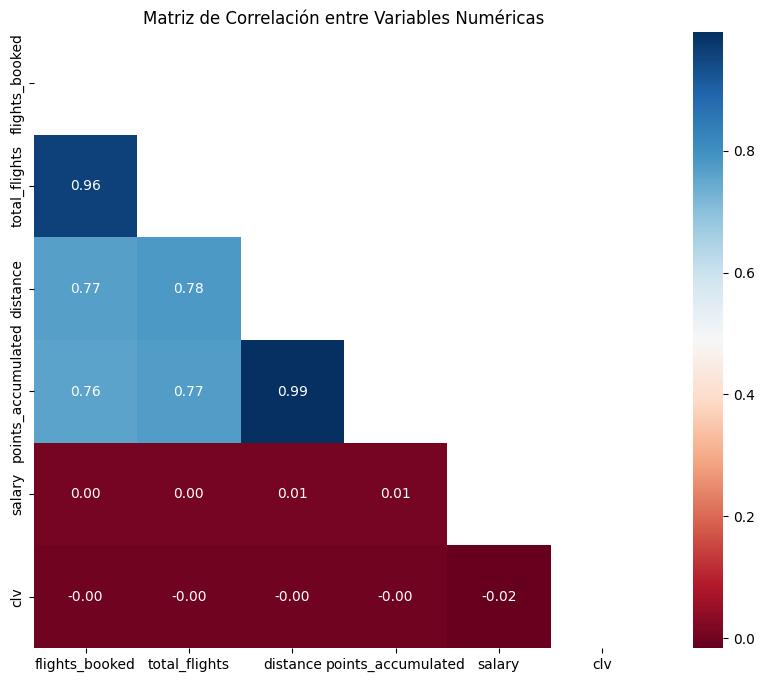

In [80]:
# Selección de columnas numéricas clave
cols_analisis = ['flights_booked', 'total_flights', 'distance', 'points_accumulated', 'salary', 'clv']


 # Identificación de Outliers con Boxplots
plt.figure(figsize=(15, 10))
for i, col in enumerate(cols_analisis):
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=df_limpio[col], color='skyblue')
    plt.title(f'Outliers en {col}')

plt.tight_layout()
plt.show()

# Análisis de Correlación
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(df_limpio[cols_analisis].corr(), dtype=bool))
sns.heatmap(df_limpio[cols_analisis].corr(), annot=True, cmap='RdBu', fmt=".2f", mask=mask)
plt.title('Matriz de Correlación entre Variables Numéricas')
plt.show()

Los outliers en estas variables no necesariamente indican errores en los datos, sino que refleja la variedad de la base de clientes. Mientras que la "caja" representa al cliente promedio, los puntos externos definen a los segmentos VIP o por debajo de la media, los cuales deben ser tratados de forma diferenciada en estrategias de marketing o modelos de predicción.

En cuanrto a la matriz de correlacion, vemos que el perfil típico del cliente de este dataset es una persona casada, con estudios universitarios y usuario de la tarjeta Star. Esta caracterización es vital para la siguiente fase de análisis, ya que permite cruzar estos perfiles con el gasto en vuelos o la acumulación de puntos para detectar patrones de consumo específicos por segmento.